In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import joblib
import os

In [11]:
df = pd.read_csv('../data/processed/features_engineered.csv')

In [ ]:
risk_features = ['Age', 'BMI', 'Heart_Rate', 'Coffee_Intake', 'Sleep_Hours']
X = df[risk_features]

In [ ]:
iso_forest = IsolationForest(n_estimators=100, contamination=0.03, random_state=42)
df['anomaly_score'] = iso_forest.fit_predict(X)

In [ ]:
anomalies = df[df['anomaly_score'] == -1]
normal = df[df['anomaly_score'] == 1]

print(f"Total Anomalies Detected: {len(anomalies)}")

Total Anomalies Detected: 300


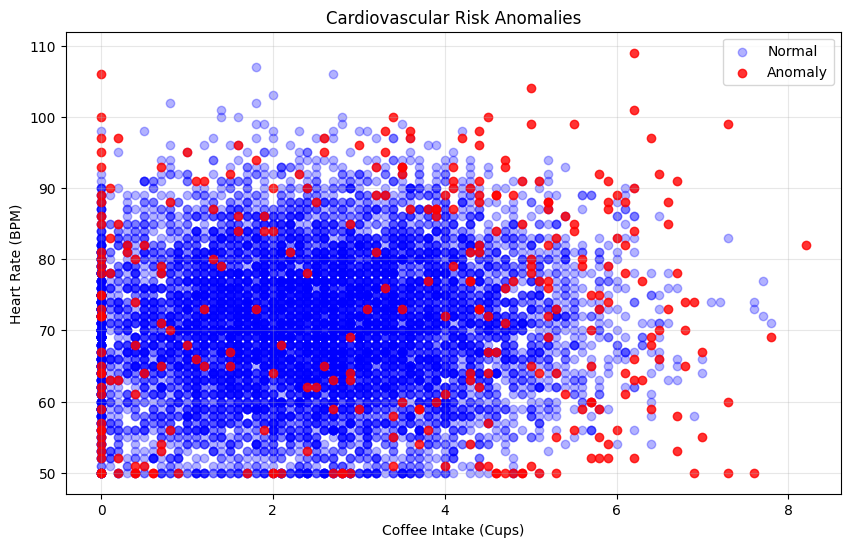

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(normal['Coffee_Intake'], normal['Heart_Rate'], color='blue', alpha=0.3, label='Normal')
plt.scatter(anomalies['Coffee_Intake'], anomalies['Heart_Rate'], color='red', alpha=0.8, label='Anomaly')

plt.title("Cardiovascular Risk Anomalies")
plt.xlabel("Coffee Intake (Cups)")
plt.ylabel("Heart Rate (BPM)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Save the model
joblib.dump(iso_forest, '../models/anomaly/iso_forest_v1.joblib')

# Save the feature list to ensure consistency in the API
with open('../models/anomaly/risk_features.txt', 'w') as f:
    f.write(",".join(risk_features))